In [95]:
import numpy as np
import pandas as pd
import matplotlib
import cv2
import scipy
import skimage

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("OpenCV:", cv2.__version__)
print("SciPy:", scipy.__version__)
print("scikit-image:", skimage.__version__)

NumPy: 2.2.6
Pandas: 2.3.3
Matplotlib: 3.10.9
OpenCV: 5.0.0
SciPy: 1.15.3
scikit-image: 0.25.2


In [96]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import morphology, segmentation, feature, measure

In [97]:
image_path = "BAC_18_0004_Croped.tif"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print("Tamaño:", img.shape)
print("Mínimo:", img.min())
print("Máximo:", img.max())

Tamaño: (2048, 2048)
Mínimo: 0
Máximo: 255


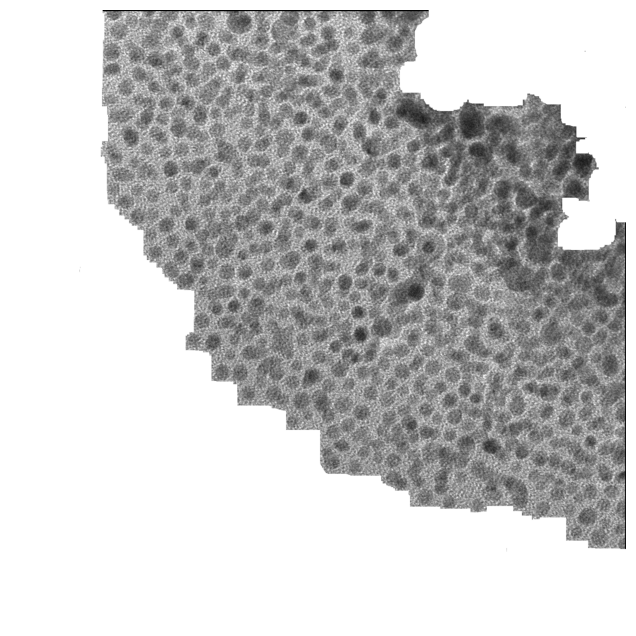

In [98]:
plt.figure(figsize=(12, 8))
plt.imshow(img, cmap="gray")
plt.axis("off");

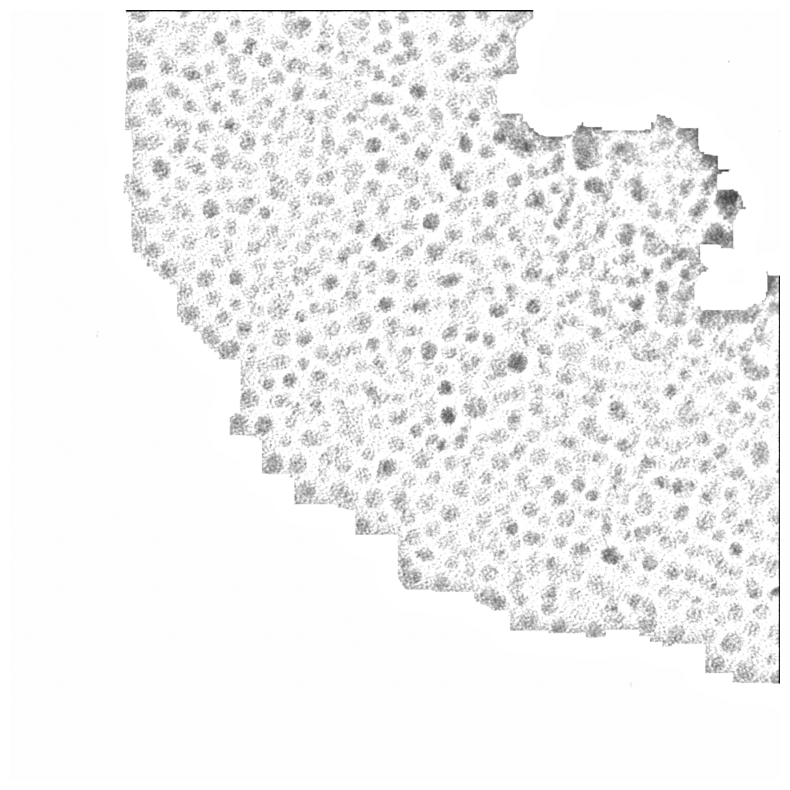

In [99]:
blur = cv2.GaussianBlur(img, (5, 5), 0)

background = cv2.GaussianBlur(
    blur,
    (0, 0),
    sigmaX=25,
    sigmaY=25
)

corrected = cv2.divide(
    blur.astype(np.float32),
    background.astype(np.float32) + 1,
    scale=255
)

corrected = np.clip(corrected, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(corrected, cmap="gray")
plt.axis("off");

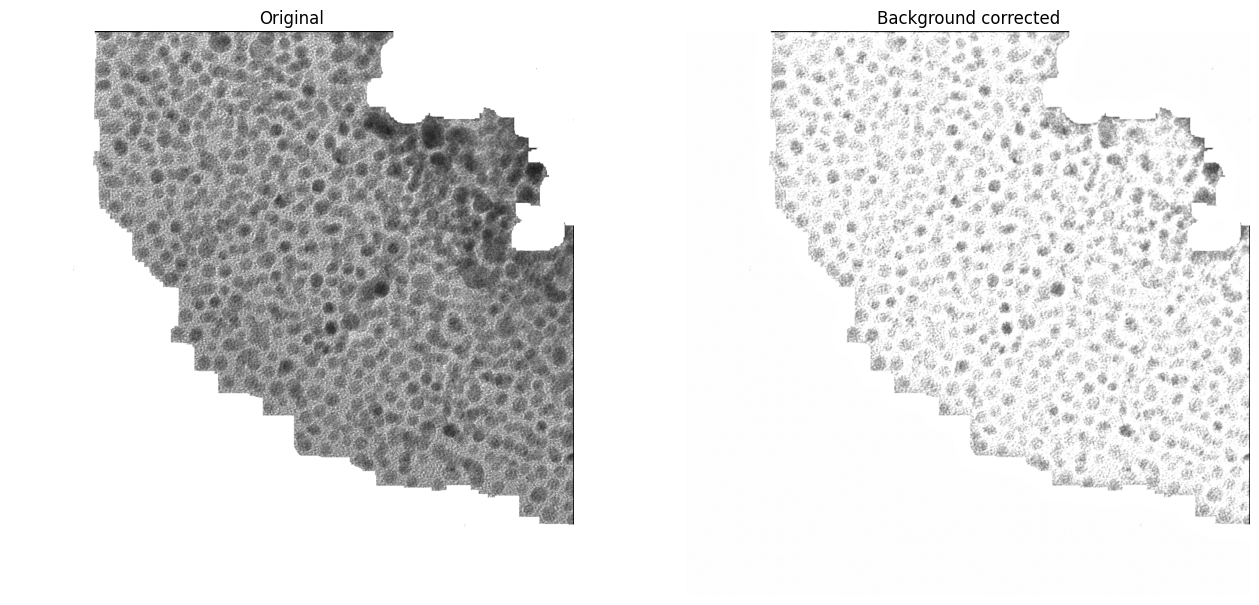

In [100]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(corrected, cmap="gray")
ax[1].set_title("Background corrected")
ax[1].axis("off")

plt.show()

Threshold: 219.0


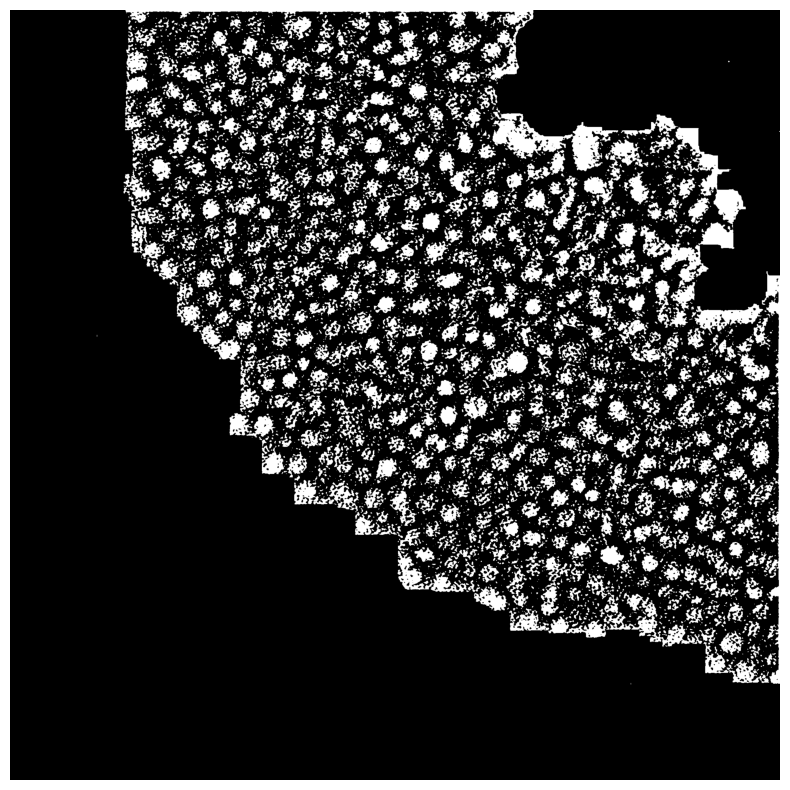

In [101]:
threshold_value, binary = cv2.threshold(
    corrected,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Threshold:", threshold_value)

plt.figure(figsize=(10,10))
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

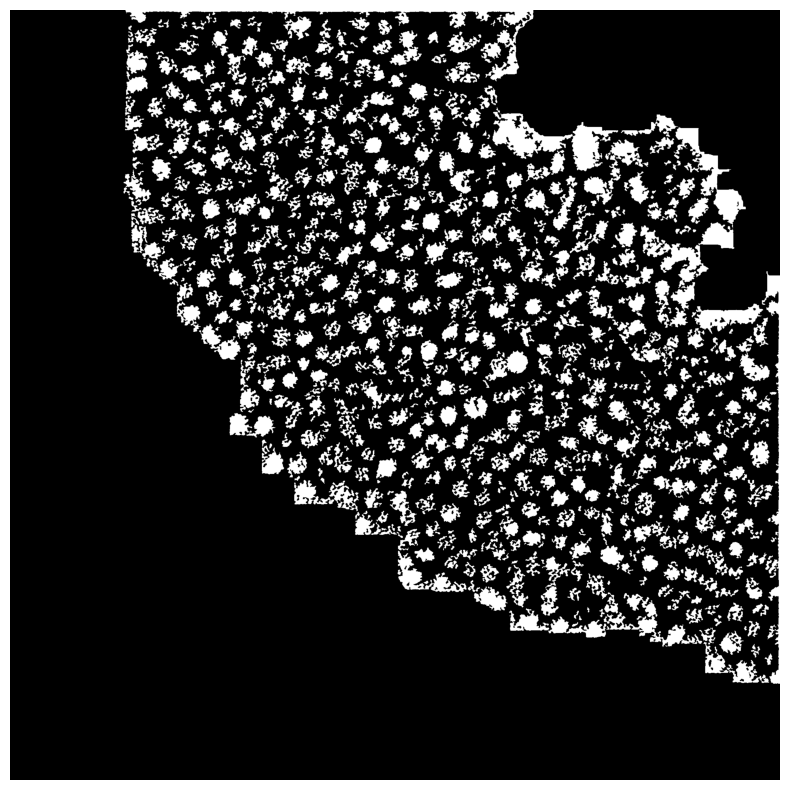

In [102]:
mask = binary > 0

mask = morphology.remove_small_objects(
    mask,
    min_size=50
)

mask = morphology.remove_small_holes(
    mask,
    area_threshold=30
)

plt.figure(figsize=(10,10))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [103]:
#plt.figure(figsize=(10, 5))
#
#plt.hist(
#    corrected.ravel(),
#    bins=256
#)
#
#plt.xlabel("Pixel intensity")
#plt.ylabel("Number of pixels")
#plt.title("Intensity histogram")
#
#plt.show()

In [104]:
#print("Otsu threshold:", threshold_value)

In [105]:
#thresholds = [120, 130, 140, 150, 160, 170, 180, 190]
#
#fig, axes = plt.subplots(2, 4, figsize=(16, 8))
#
#for ax, t in zip(axes.ravel(), thresholds):
#
#    test = corrected < t
#
#    ax.imshow(test, cmap="gray")
#    ax.set_title(f"Threshold = {t}")
#    ax.axis("off")
#
#plt.tight_layout()
#plt.show()

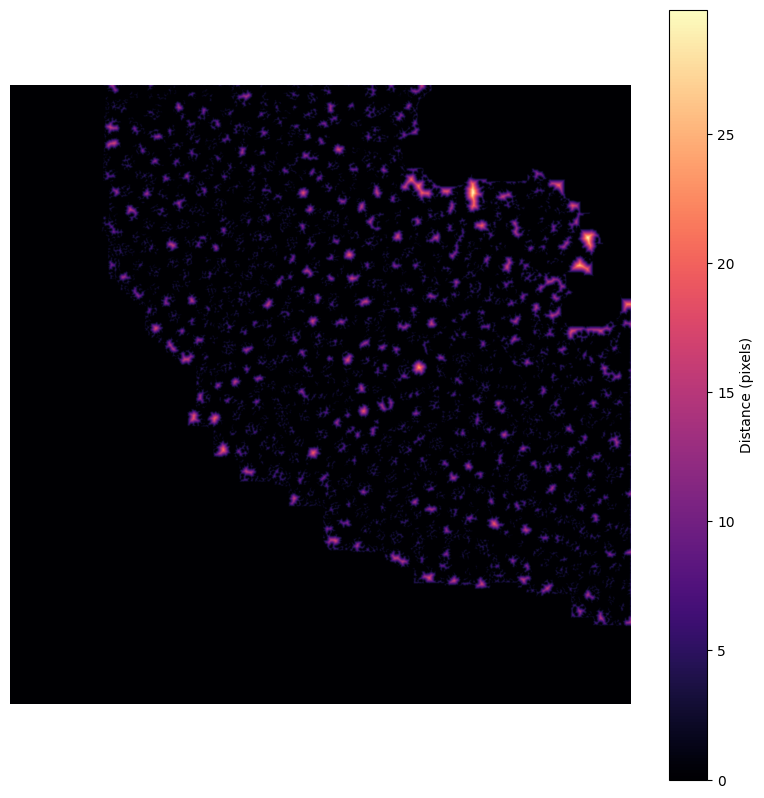

In [106]:
distance = ndi.distance_transform_edt(mask)

plt.figure(figsize=(10, 10))
plt.imshow(distance, cmap="magma")
plt.colorbar(label="Distance (pixels)")
plt.axis("off")
plt.show()

In [107]:
coordinates = feature.peak_local_max(
    distance,
    min_distance=35,
    labels=mask
)

print("Número de centros encontrados:", len(coordinates))

Número de centros encontrados: 403


In [108]:
markers = np.zeros(distance.shape, dtype=np.int32)

for i, (y, x) in enumerate(coordinates, start=1):
    markers[y, x] = i

markers = ndi.label(markers > 0)[0]

print("Markers:", markers.max())

Markers: 403


In [109]:
labels = segmentation.watershed(
    -distance,
    markers,
    mask=mask
)

print("Partículas detectadas:", labels.max())

Partículas detectadas: 403


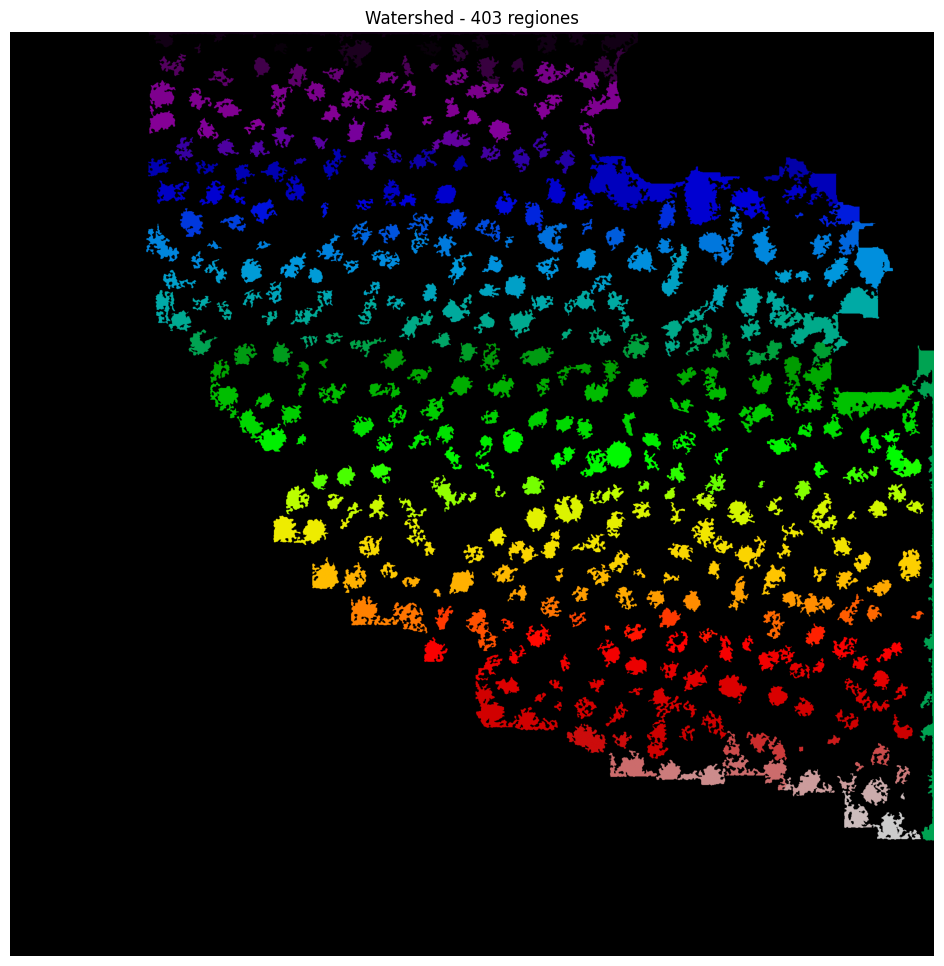

In [110]:
plt.figure(figsize=(12, 12))

plt.imshow(labels, cmap="nipy_spectral")

plt.title(f"Watershed - {labels.max()} regiones")
plt.axis("off")

plt.show()

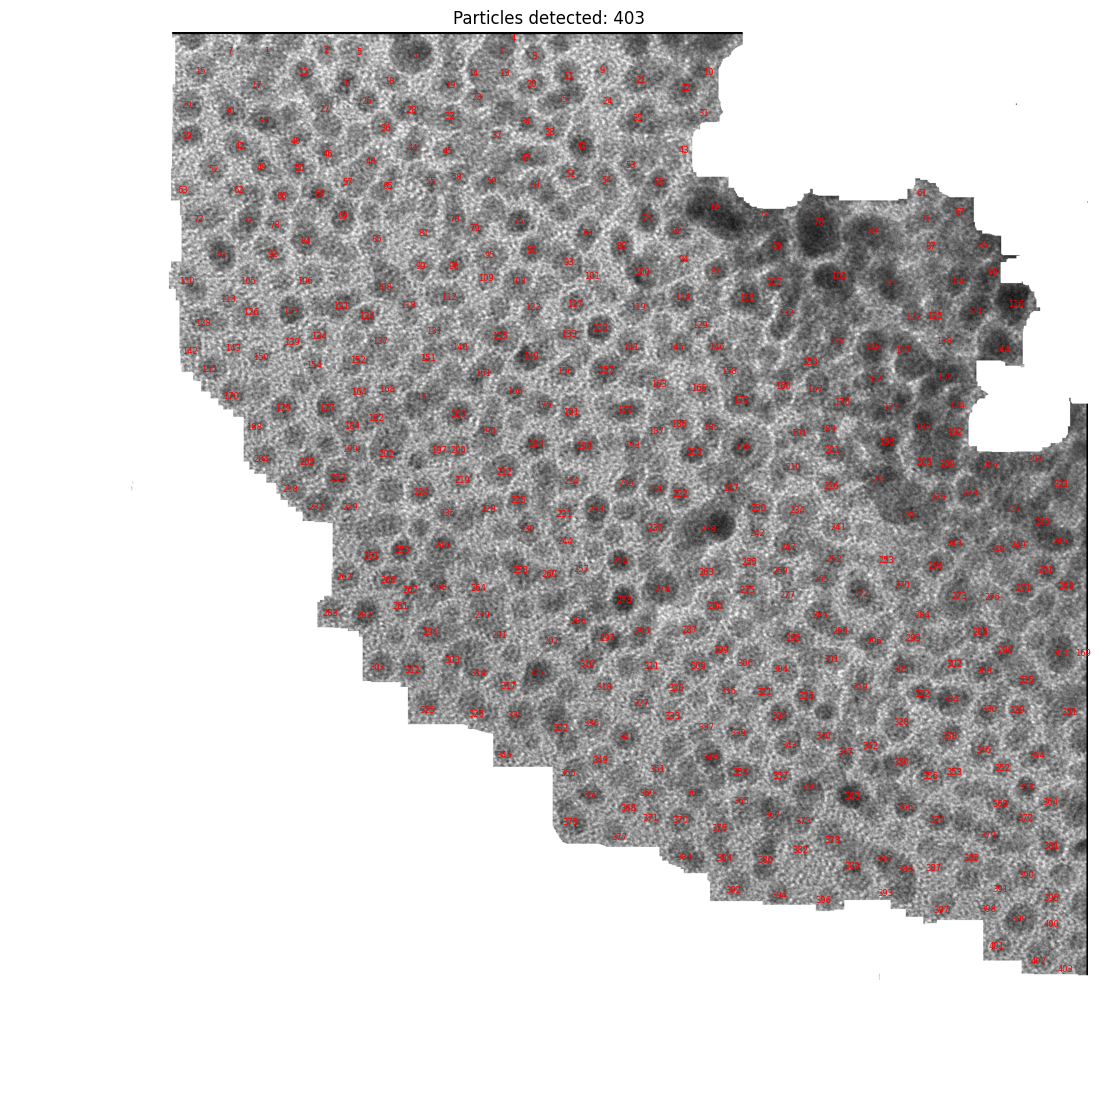

In [111]:
regions = measure.regionprops(labels)

fig, ax = plt.subplots(figsize=(14, 14))

ax.imshow(img, cmap="gray")

for region in regions:

    y, x = region.centroid

    ax.text(
        x,
        y,
        str(region.label),
        color="red",
        fontsize=6,
        ha="center",
        va="center"
    )

ax.axis("off")
ax.set_title(f"Particles detected: {len(regions)}")

plt.show()

In [112]:
regions = measure.regionprops(labels)

print("Número total de partículas:", len(regions))

Número total de partículas: 403


In [113]:
nm_per_pixel = 20 / 210

print("Escala:", nm_per_pixel, "nm/pixel")

Escala: 0.09523809523809523 nm/pixel


In [114]:
results = []

for region in regions:

    area_px = region.area

    area_nm2 = area_px * nm_per_pixel**2

    perimeter_px = region.perimeter
    perimeter_nm = perimeter_px * nm_per_pixel

    equivalent_diameter_nm = (
        region.equivalent_diameter *
        nm_per_pixel
    )

    y, x = region.centroid

    circularity = (
        4 * np.pi * area_px /
        perimeter_px**2
        if perimeter_px > 0
        else np.nan
    )

    results.append({
        "Particle": region.label,
        "Area_pixels2": area_px,
        "Area_nm2": area_nm2,
        "Equivalent_diameter_nm": equivalent_diameter_nm,
        "Perimeter_pixels": perimeter_px,
        "Perimeter_nm": perimeter_nm,
        "Circularity": circularity,
        "Centroid_X": x,
        "Centroid_Y": y
    })

df = pd.DataFrame(results)

In [115]:
df.head(845)

,Particle,Area_pixels2,Area_nm2,Equivalent_diameter_nm,Perimeter_pixels,Perimeter_nm,Circularity,Centroid_X,Centroid_Y
0,1,52.0,0.471655,0.774939,26.278175,2.502683,0.946287,488.057692,35.403846
1,2,421.0,3.818594,2.204991,129.018290,12.287456,0.317826,599.864608,34.719715
2,3,854.0,7.746032,3.140470,280.557395,26.719752,0.136340,931.422717,36.233021
3,4,11140.0,101.043084,11.342489,3450.132214,328.584020,0.011760,955.213016,11.179803
4,5,78.0,0.707483,0.949102,37.935029,3.612860,0.681120,662.769231,37.743590
...,...,...,...,...,...,...,...,...,...
398,399,1960.0,17.777778,4.757664,487.386868,46.417797,0.103686,1917.351020,1684.795408
399,400,74.0,0.671202,0.924446,36.970563,3.521006,0.680345,1978.216216,1694.445946
400,401,2369.0,21.487528,5.230561,535.788889,51.027513,0.103702,1872.789363,1735.937526
401,402,2481.0,22.503401,5.352777,537.836616,51.222535,0.107779,1952.621121,1764.349053


In [116]:
df_filtered = df[
    (df["Area_nm2"] >= 5) &
    (df["Area_nm2"] <= 60)
].copy()

In [117]:
print("Partículas originales:", len(df))
print("Partículas después del filtro:", len(df_filtered))

Partículas originales: 403
Partículas después del filtro: 314


In [118]:
df_filtered.head(845)

,Particle,Area_pixels2,Area_nm2,Equivalent_diameter_nm,Perimeter_pixels,Perimeter_nm,Circularity,Centroid_X,Centroid_Y
2,3,854.0,7.746032,3.140470,280.557395,26.719752,0.136340,931.422717,36.233021
5,6,2162.0,19.609977,4.996819,463.623412,44.154611,0.126396,767.307586,44.067993
7,8,780.0,7.074830,3.001325,251.486327,23.951079,0.154980,995.624359,45.350000
9,10,1655.0,15.011338,4.371845,467.067063,44.482577,0.095334,1326.079154,75.270695
10,11,1618.0,14.675737,4.322699,349.770599,33.311486,0.166196,1060.144623,83.024722
...,...,...,...,...,...,...,...,...,...
396,397,2612.0,23.691610,5.492276,607.972655,57.902158,0.088800,1769.322741,1667.422282
397,398,585.0,5.306122,2.599224,252.994949,24.094757,0.114853,1857.449573,1666.083761
398,399,1960.0,17.777778,4.757664,487.386868,46.417797,0.103686,1917.351020,1684.795408
400,401,2369.0,21.487528,5.230561,535.788889,51.027513,0.103702,1872.789363,1735.937526


In [119]:
print("====================================")
print("     NANOPARTICLE ANALYSIS")
print("====================================")

print(f"\nTotal de partículas detectadas: {len(df)}")
print(f"Partículas después del filtro: {len(df_filtered)}")

print(
    f"Porcentaje conservado: "
    f"{100 * len(df_filtered) / len(df):.2f}%"
)

     NANOPARTICLE ANALYSIS

Total de partículas detectadas: 403
Partículas después del filtro: 314
Porcentaje conservado: 77.92%


In [120]:
area_stats = df_filtered["Area_nm2"].describe()

print(area_stats)

count    314.000000
mean      12.346751
std        6.747042
min        5.043084
25%        8.154195
50%       10.317460
75%       14.743764
max       56.643991
Name: Area_nm2, dtype: float64


In [121]:
mean_area = df_filtered["Area_nm2"].mean()
std_area = df_filtered["Area_nm2"].std()
median_area = df_filtered["Area_nm2"].median()

print(f"Área promedio  = {mean_area:.3f} nm²")
print(f"Desviación     = {std_area:.3f} nm²")
print(f"Mediana        = {median_area:.3f} nm²")
print(f"Mínimo         = {df_filtered['Area_nm2'].min():.3f} nm²")
print(f"Máximo         = {df_filtered['Area_nm2'].max():.3f} nm²")

Área promedio  = 12.347 nm²
Desviación     = 6.747 nm²
Mediana        = 10.317 nm²
Mínimo         = 5.043 nm²
Máximo         = 56.644 nm²


In [122]:
diameter = df_filtered["Equivalent_diameter_nm"]

print(f"Diámetro equivalente promedio = {diameter.mean():.3f} nm")
print(f"Desviación estándar           = {diameter.std():.3f} nm")
print(f"Mediana                       = {diameter.median():.3f} nm")
print(f"Mínimo                        = {diameter.min():.3f} nm")
print(f"Máximo                        = {diameter.max():.3f} nm")

Diámetro equivalente promedio = 3.852 nm
Desviación estándar           = 0.942 nm
Mediana                       = 3.624 nm
Mínimo                        = 2.534 nm
Máximo                        = 8.492 nm


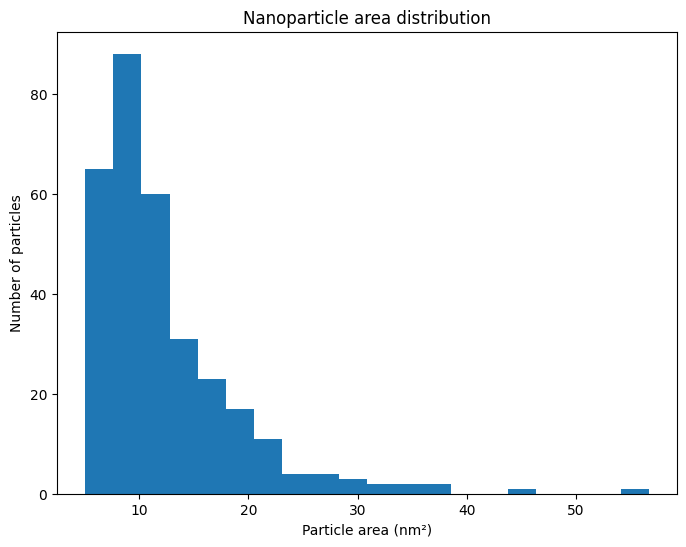

In [123]:
plt.figure(figsize=(8, 6))

plt.hist(
    df_filtered["Area_nm2"],
    bins=20
)

plt.xlabel("Particle area (nm²)")
plt.ylabel("Number of particles")
plt.title("Nanoparticle area distribution")

plt.show()

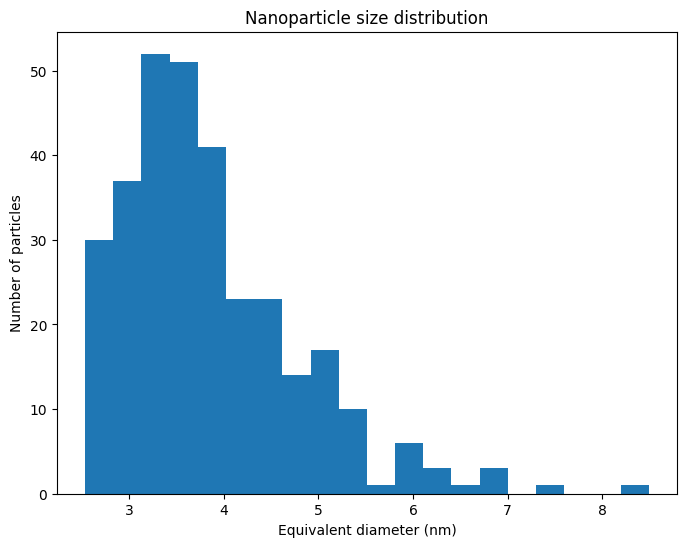

In [124]:
plt.figure(figsize=(8, 6))

plt.hist(
    df_filtered["Equivalent_diameter_nm"],
    bins=20
)

plt.xlabel("Equivalent diameter (nm)")
plt.ylabel("Number of particles")
plt.title("Nanoparticle size distribution")

plt.show()

In [129]:
areas_diametros = df_filtered[
    ["Particle", "Area_nm2", "Equivalent_diameter_nm"]
].copy()

areas_diametros.columns = [
    "Particle",
    "Area (nm²)",
    "Equivalent diameter (nm)"
]

areas_diametros.to_excel(
    "nanoparticle_areas_diameters.xlsx",
    index=False
)

print("Archivo creado correctamente.")

Archivo creado correctamente.
